### İş Uygulaması: Bahşiş ile Ödenen Hesap Arasındaki İlişkinin İncelenmesi

**Bahşiş ile ödenen hesap arasında korelasyon var mı?**

$$
\begin{aligned}
H_0&: \rho = 0 \\
H_1&: \rho \neq 0
\end{aligned}
$$


## Korelasyon Analizi

Bahşiş veri seti:

total_bill: yemeğin toplam fiyatı (bahşiş ve vergi dahil)

tip: bahşiş

sex: ücreti ödeyen kişinin cinsiyeti (0=male, 1=female)

smoker: grupta sigara içen var mı? (0=No, 1=Yes)

day: gün (3=Thur, 4=Fri, 5=Sat, 6=Sun)

time: ne zaman? (0=Day, 1=Night)

size: grupta kaç kişi var?


In [1]:
import seaborn as sns
tips = sns.load_dataset('tips')
df = tips.copy()
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


*Burada bir problem var. Bizden sadece bahşiş ile ödenen hesap arasındaki ilişkinin araştırılması isteniyor. Fakat veri setimizdeki total_bill değişkeninde bahşiş değeri var. Burada arındırma yapmamız gerekiyor ki gerçekten bahşiş ile hesap ücreti arasındaki ilişkiyi sağlıklı bir şekilde inceleyebilelim.*

*ödenen toplam hesap şöyle bulunur: **total_bill** değişkeninden **tip** değişkeni çıkarılır.*

In [2]:
df["total_bill"] = df["total_bill"] - df["tip"]

In [3]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,15.98,1.01,Female,No,Sun,Dinner,2
1,8.68,1.66,Male,No,Sun,Dinner,3
2,17.51,3.50,Male,No,Sun,Dinner,3
3,20.37,3.31,Male,No,Sun,Dinner,2
4,20.98,3.61,Female,No,Sun,Dinner,4


*Artık veri setimiz korelasyon ilişkisi araştırması için hazır.*

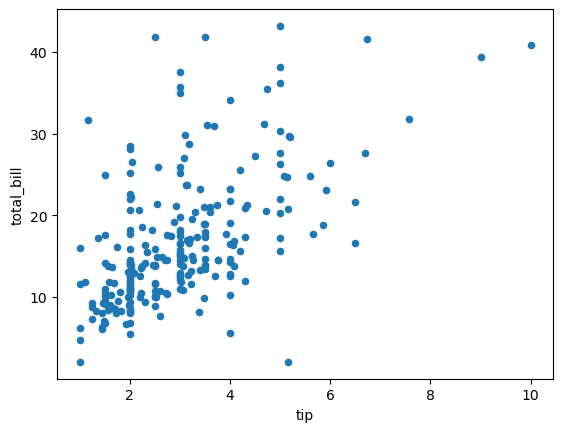

In [4]:
df.plot.scatter("tip", "total_bill");

#### Korelasyon Varsayım Kontrolü

In [5]:
from scipy.stats import shapiro

In [6]:
test_istatistigi, pvalue = shapiro(df["tip"])
print("Test İstatistiği : %.4f, p değeri: %.4f" % (test_istatistigi, pvalue))

Test İstatistiği : 0.8978, p değeri: 0.0000


In [7]:
test_istatistigi, pvalue = shapiro(df["total_bill"])
print("Test İstatistiği : %.4f, p değeri: %.4f" % (test_istatistigi, pvalue))

Test İstatistiği : 0.9136, p değeri: 0.0000


*İki değişkenimiz için de p-value değerlerimiz 0.05'ten çok küçük.H0 reddedilir. Yani değişkenlerin örnek normal dağılımı ile teorik dağılımı arasında anlamlı bir fark vardır."*

*Şimdilik bu fark yokmuş gibi parametrik hipotez testimizi yapacağız.*

#### Hipotez Testi

##### Korelasyon Katsayısı

In [8]:
 df["tip"].corr(df["total_bill"])

np.float64(0.5766634471096382)

*corr() metodu ön tanımlı olarak pearson korelasyon katsayısını verir. Fakat bu normallik varsayımı sağlandığında geçerlidir. O yüzden normallik varsayımı sağlanmadığında kullanılan spearman korelasyon katsayısını kullanırız.*

In [9]:
 df["tip"].corr(df["total_bill"], method = "spearman")

np.float64(0.593691939408997)

*Korelasyon yorumlamalarında parametrik veya nonparametrik olması bir anlam ifade etmiyor. Sadece çıkan sonuca odaklanırsak değişkenler arasında orta şiddette,pozitif yönlü bir korelasyon olduğunu görebiliriz. Peki bu ilişki anlamlı mı?*

##### Korelasyon Anlamlılığının Testi

In [10]:
from scipy.stats import pearsonr

In [11]:
#normallik varsayımı sağlanıyormuş gibi test ediyoruz
test_istatistigi, pvalue = pearsonr(df["tip"], df["total_bill"])
print("Korelasyon Katsayısı : %.4f, p değeri: %.4f" % (test_istatistigi, pvalue))

Korelasyon Katsayısı : 0.5767, p değeri: 0.0000


*Yorum: 'Değişenler arasında anlamlı bir ilişki yoktur' iddiasını savunan H0 hipotezini reddediyoruz. Yani değişkenler arasında anlamlı bir ilişki vardır."*

### Nonparametrik Hipotez Testi

In [12]:
from scipy.stats import spearmanr
spearmanr(df["tip"], df["total_bill"])

SignificanceResult(statistic=np.float64(0.593691939408997), pvalue=np.float64(1.2452285137560329e-24))

In [13]:
test_istatistigi, pvalue = spearmanr(df["tip"], df["total_bill"])
print("Korelasyon Katsayısı : %.4f, p değeri: %.4f" % (test_istatistigi, pvalue))

Korelasyon Katsayısı : 0.5937, p değeri: 0.0000


# ŞİMDİ BİZ NE YAPTIK ? 

*iki değişken arasında anlamlı bir ilişki olup olmadığına karar vermek için korelasyon testi yapmaya karar verdik. Fakat öncesinde varsayım kontrolü yaptık. Eğer korelasyon testi yapacağımız değişkenlerin normal dağılımı ile teorik dağılımı arasında anlamlı bir fark varsa (varsayım sağlanmıyorsa) korelasyon testi sırasında **spearman korelasyon katsayısı**'nı; Eğer normal dağılımı ile teorik dağılımı arasında bir fark yoksa(varsayım sağlanıyorsa) **pearson korelasyon katsayısı**'nı kullanırız. Normallik varsayımını sağlayamadığımız için spearman'ı kullandık.*

*p-value değeri kabul edilebilir hata eşik değeri olan alpha değerinin yani 0.05'in çok altında. Bu yüzden H0'ın savunduğu değişkenler arasında anlamlı bir ilişki yoktur savını burada çürüttük. İki değişken arasında pozitif yönde orta şiddette bir korelasyon vardır sonucunu çıkarttık(0.5937).*

*Garanti olsun istersek yapacağımız bir test daha var: Kendall-Tau testi:*

In [14]:
from scipy.stats import kendalltau
test_istatistigi, pvalue = kendalltau(df["tip"], df["total_bill"])
print("Korelasyon Katsayısı : %.4f, p değeri: %.4f" % (test_istatistigi, pvalue))

Korelasyon Katsayısı : 0.4401, p değeri: 0.0000


*Bu 3 test içerisinden en güvenilir olanı, normallik varsayımını sağlayamadığımız için spearman korelasyon katsayısı testidir.*